In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [40]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / "data" / "top_volume_stocks"
msft_path = RAW_DIR / "MSFT.csv"
print(msft_path)
df = pd.read_csv(msft_path)

D:\cs3244-stock-forecasting\data\top_volume_stocks\MSFT.csv


In [41]:
#drop duplication values
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").drop_duplicates()

In [42]:
#get values in the correct range
df = df[(df["Date"] >= "2009-01-01") & (df["Date"] <= "2017-12-31")].copy()


In [43]:
#integrity checks
print("Nulls:\n", df.isna().sum())
print("Duplicates:", df.duplicated().sum())
print("Date range:", df["Date"].min(), "to", df["Date"].max())

Nulls:
 Date       0
Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64
Duplicates: 0
Date range: 2009-01-02 00:00:00 to 2017-11-10 00:00:00


In [44]:
#Feature engineering
df["DailyReturn"] = df["Close"].pct_change()
df["NormalizedClose"] = df["Close"] / df["Close"].iloc[0] * 100
df["Volatility20"] = df["DailyReturn"].rolling(20).std()
df["MA20"] = df["Close"].rolling(20).mean()
df["MA50"] = df["Close"].rolling(50).mean()


In [45]:
#Summary stats
summary = {
    "avg_daily_return": df["DailyReturn"].mean(),
    "volatility_daily": df["DailyReturn"].std(),
    "avg_volume": df["Volume"].mean(),
    "min_daily_return": df["DailyReturn"].min(),
    "max_daily_return": df["DailyReturn"].max(),
}
print(summary)

{'avg_daily_return': 0.0008328001889917616, 'volatility_daily': 0.01539371846004315, 'avg_volume': 51105168.37724014, 'min_daily_return': -0.11705335712966947, 'max_daily_return': 0.10511721704058496}


**Plotting a time series of closing price**

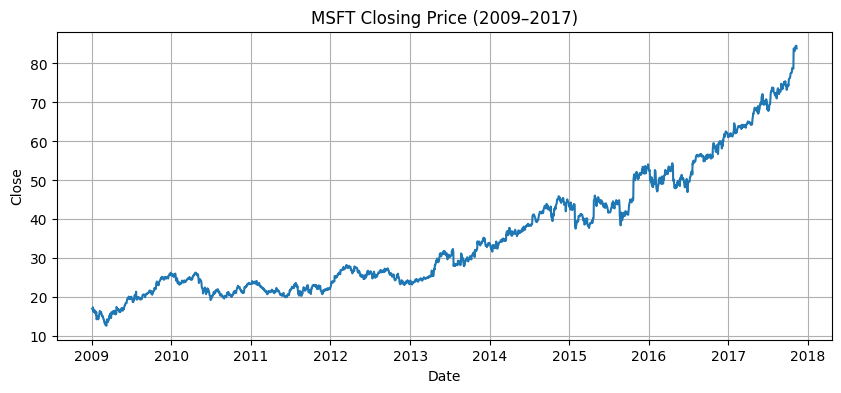

In [46]:
plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["Close"])
plt.title("MSFT Closing Price (2009–2017)")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.show()

This shows the raw time series of MSFT closing price.
We see a strong upward trend over the period, especially after 2013, indicating long-term growth.
Any short-term dips are likely market corrections, but the overall direction is positive.

**Plotting a time series of normalized price**

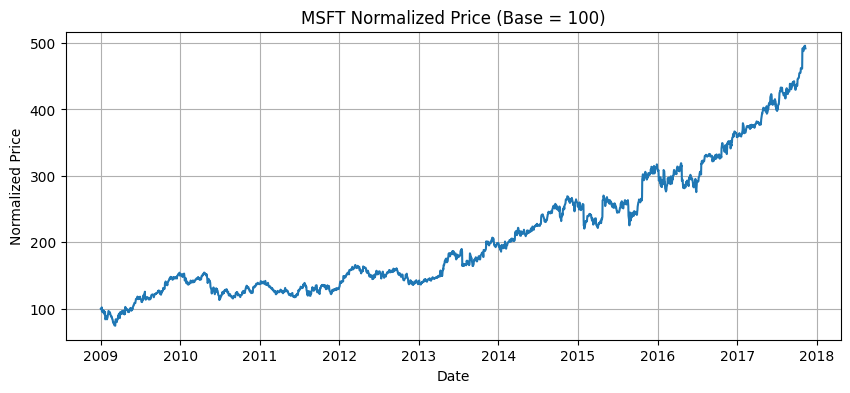

In [47]:
plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["NormalizedClose"])
plt.title("MSFT Normalized Price (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.grid(True)
plt.show()

By normalizing to 100 at the start, this plot makes relative growth easy to compare.
It confirms compounding gains over time: MSFT’s price rose many times above the baseline.
This also highlights periods of faster growth and flattening without scale bias.

**Ploting a time series of trading volumn**

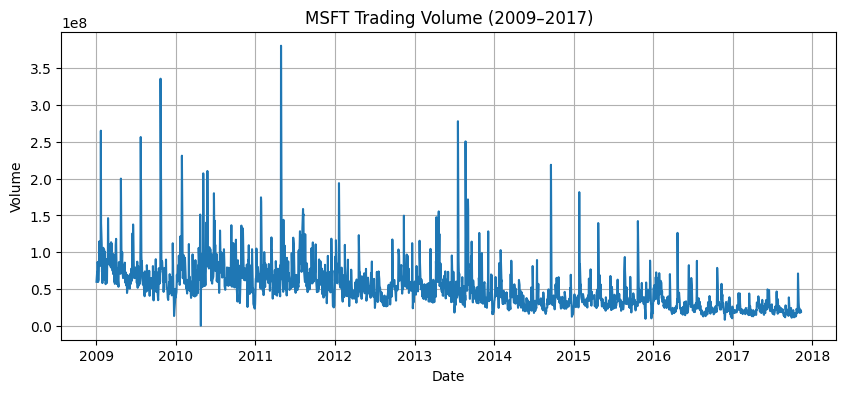

In [48]:
plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["Volume"])
plt.title("MSFT Trading Volume (2009–2017)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()


Volume is noisy and spikes on certain days (earnings, news, macro events).
Persistent higher volume periods typically align with major price moves (volatility).
A rising or plateauing volume trend supports sustained investor interest.

**Plotting a histogram of daily return distribution**

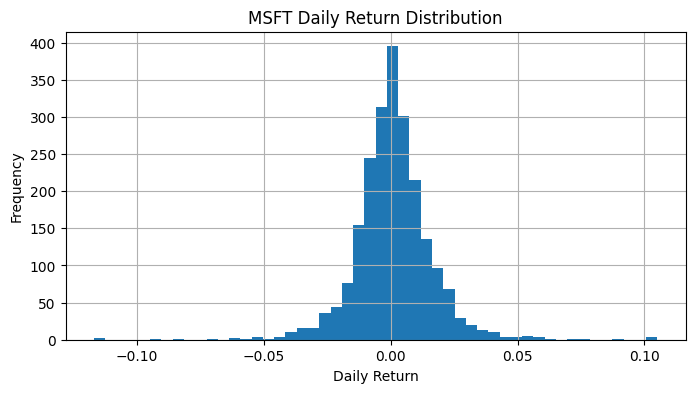

In [49]:

plt.figure(figsize=(8,4))
plt.hist(df["DailyReturn"].dropna(), bins=50)
plt.title("MSFT Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

Daily returns are centered near zero, with a narrow peak: most daily moves are small.
The tails show occasional larger positive and negative returns (fat tails).
This distribution supports the idea that price changes are mostly stable but occasionally volatile.

**Plotting a time series of adjusted open and close price**

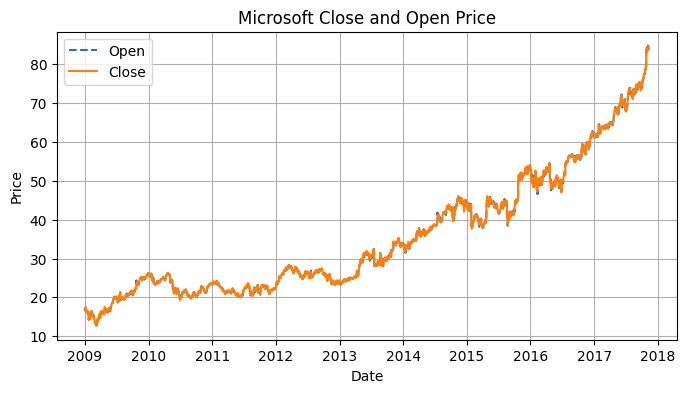

In [50]:
# Plot time series of open vs close stock price
plt.figure(figsize=(8, 4))
plt.plot(df.Date, df.Open, label='Open', linestyle='--')

plt.plot(df.Date, df.Close, label='Close', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Microsoft Close and Open Price')
plt.legend()
plt.grid()
plt.show()

Open and close track closely, with small intraday deviations.
The gap between open and close is generally small, supporting low daily directional drift compared to long-term trend.
This plot confirms stock-level stability and that close price fully captures trend.

**Plotting a histogram of a stock's closing price**

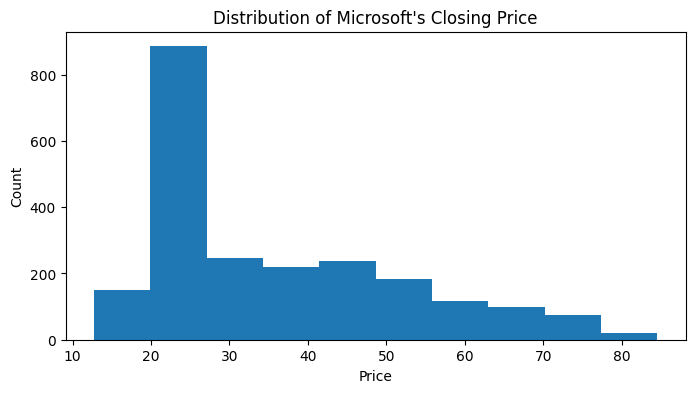

In [51]:
# Plot the histogram of Microsoft's closing price
plt.figure(figsize=(8, 4))
plt.hist(df.Close)
plt.title("Distribution of Microsoft's Closing Price")
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()


The closing prices are skewed right (because the price grows over time).
Bulk of values are at lower price range (earlier years), with fewer high-price days later.
This reinforces that the dataset covers a growth phase: more days at lower values and fewer at high values.

**Plot time series of close, MA20, and MA50 stock price**

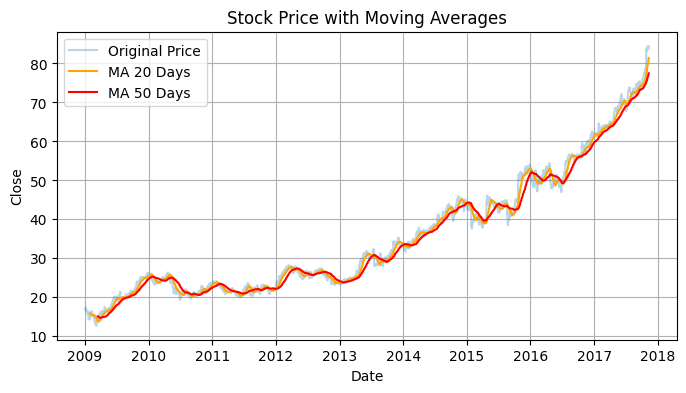

In [52]:
# Plot time series of close, MA20, and MA50 stock price
plt.figure(figsize=(8, 4))
sns.lineplot(data=df, x=df['Date'], y='Close', alpha=0.3, label='Original Price')
sns.lineplot(data=df, x=df['Date'], y='MA20', label='MA 20 Days', color='orange')
sns.lineplot(data=df, x=df['Date'], y='MA50', label='MA 50 Days', color='red')
plt.title('Stock Price with Moving Averages')
plt.legend()
plt.grid()
plt.show()


MA20 (short-term) reacts faster to price moves; MA50 smooths more slowly.
When close crosses above MAs, that often indicates momentum continuation; crosses below can signal pullbacks.
This plot highlights trend direction and potential support/resistance from moving averages.

**Calculating rolling volatility of a stock's price**

Volatility is a measure of how much a stock’s returns fluctuate.
High volatility means that the stock price changes sharply, indicating higher risk. Low volatility means that the price is more stable, indicating lower risk. When calculating rolling volatility, investors can monitor how a stock’s risk changes over time, adjust their portfolios to maintain their desired risk level. A common way to calculate volatility is by using the standard deviation of returns for a stock over time.

In [53]:
# Define the window size for the rolling calculation, 5 trading days per week
window_size = 5

In [54]:
# Calculate rolling one-week (5-trading-day) volatility of the closing price level
df['one_week_price_volatility'] = df.Close.rolling(window_size).std()


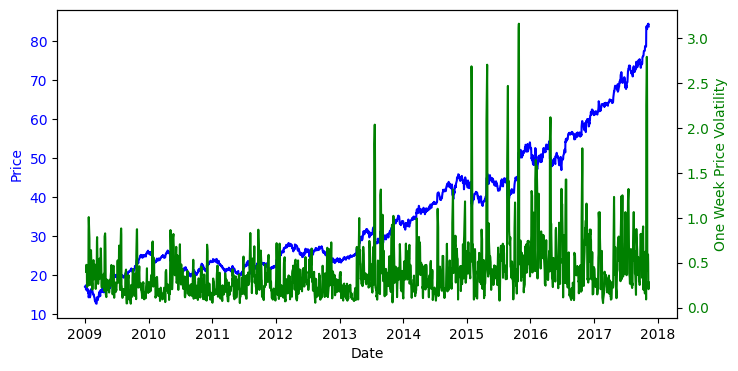

In [55]:
# Plot the calculated rolling weekly volatility of Microsoft's closing price level against Microsoft's closing price
PRICE_COLOR = 'blue'
VOL_COLOR = 'green'
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(df.Date, df.Close, label='Price', color=PRICE_COLOR)

ax1.set_xlabel("Date")
ax1.set_ylabel("Price", color=PRICE_COLOR)
ax1.tick_params(axis="y", labelcolor=PRICE_COLOR)

ax2 = ax1.twinx()
ax2.plot(df.Date, df.one_week_price_volatility, label='Price Volatility', color=VOL_COLOR)
ax2.set_ylabel("One Week Price Volatility", color=VOL_COLOR)
ax2.tick_params(axis="y", labelcolor=VOL_COLOR)

plt.show()

Price grows upward while weekly volatility oscillates.
Volatility spikes often happen near price corrections/drawdowns (risk increases during sharp moves).
Periods with low volatility and rising price suggest stable growth; high volatility suggests uncertain, riskier regimes.
